In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Fungsi bantu untuk menampilkan gambar berdampingan
def tampilkan_perbandingan(judul_list, gambar_list):
    n = len(gambar_list)
    plt.figure(figsize=(5*n, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.title(judul_list[i], fontweight='bold')
        plt.imshow(gambar_list[i], cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

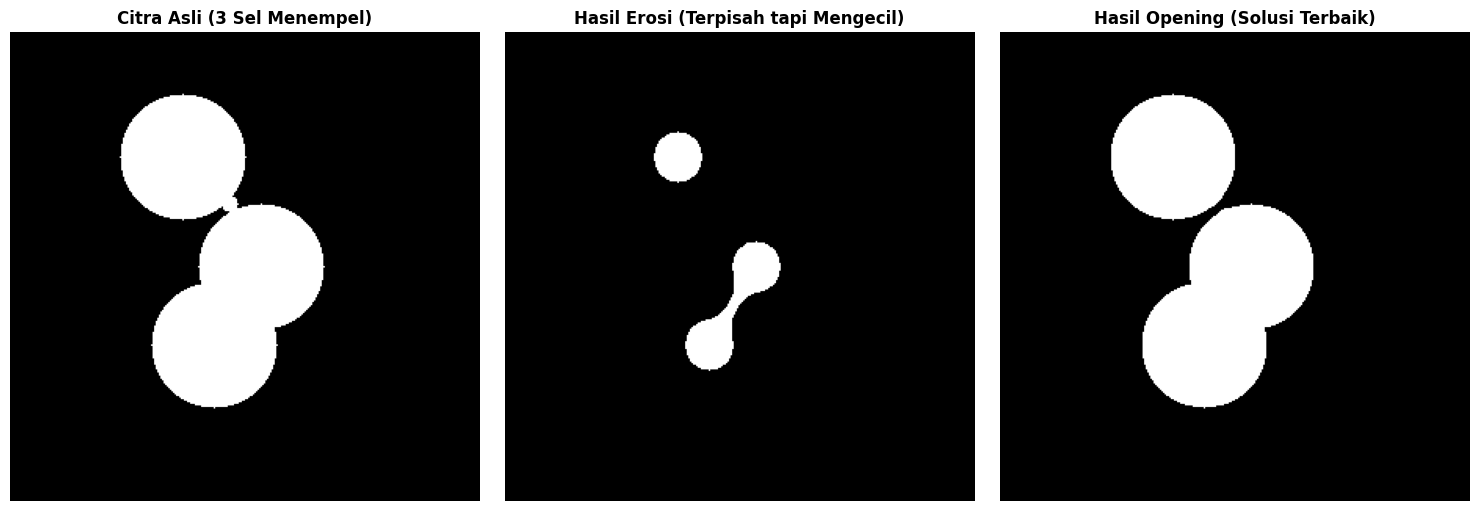

In [2]:
# 1. MENSINTESIS GAMBAR SEL MENEMPEL
citra_sel = np.zeros((300, 300), dtype=np.uint8)
# Membuat 3 sel yang saling bersinggungan/menempel
cv2.circle(citra_sel, (110, 80), 40, 255, -1)
cv2.circle(citra_sel, (160, 150), 40, 255, -1)
cv2.circle(citra_sel, (130, 200), 40, 255, -1)
cv2.circle(citra_sel, (140, 110), 5, 255, -1)

# 2. DEFINISIKAN STRUCTURING ELEMENT (Bentuk Lingkaran agar halus)
kernel_sel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))

# 3. EKSPERIMEN: EROSI vs OPENING
# Erosi mengikis sel hingga sambungannya putus, TAPI sel menjadi sangat kecil
hasil_erosi = cv2.erode(citra_sel, kernel_sel, iterations=2)

# Opening (Erosi lalu Dilasi). Sambungan putus, tapi ukuran sel kembali membesar!
hasil_opening = cv2.morphologyEx(citra_sel, cv2.MORPH_OPEN, kernel_sel)

# Tampilkan
tampilkan_perbandingan(
    ["Citra Asli (3 Sel Menempel)", "Hasil Erosi (Terpisah tapi Mengecil)", "Hasil Opening (Solusi Terbaik)"],
    [citra_sel, hasil_erosi, hasil_opening]
)

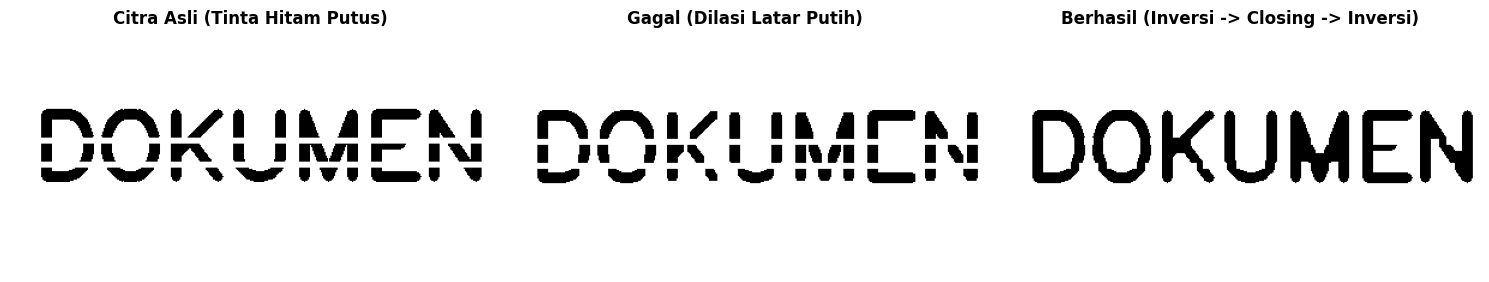

In [11]:
# 1. MENSINTESIS TULISAN PUTUS-PUTUS (Tinta Hitam, Kertas Putih)
kertas = np.ones((200, 400), dtype=np.uint8) * 255
cv2.putText(kertas, "DOKUMEN", (20, 120), cv2.FONT_HERSHEY_SIMPLEX, 2.5, 0, 8)
# Menambahkan garis putih melintang untuk mensimulasikan huruf yang terpotong/putus
cv2.line(kertas, (0, 90), (400, 90), 255, 3)
cv2.line(kertas, (0, 110), (400, 110), 255, 3)

kernel_teks = np.ones((6, 6), np.uint8)

# 2. EKSPERIMEN GAGAL: Langsung di-Closing tanpa analisis
# Niatnya menyambung garis hitam yang putus, malah hurufnya termakan!
gagal_closing = cv2.morphologyEx(kertas, cv2.MORPH_CLOSE, kernel_teks)

# 3. EKSPERIMEN BERHASIL: Pahami Konsep Foreground (Objek Utama = Putih)
# Inversi dulu gambarnya (Teks jadi Putih, Kertas jadi Hitam)
kertas_inversi = cv2.bitwise_not(kertas)
# Lakukan Closing (Dilasi lalu Erosi). Garis putih (teks) yang putus akan tersambung!
sukses_closing_inv = cv2.morphologyEx(kertas_inversi, cv2.MORPH_CLOSE, kernel_teks)
# Inversi kembali ke warna asal
sukses_closing = cv2.bitwise_not(sukses_closing_inv)

# Tampilkan
tampilkan_perbandingan(
    ["Citra Asli (Tinta Hitam Putus)", "Gagal (Dilasi Latar Putih)", "Berhasil (Inversi -> Closing -> Inversi)"],
    [kertas, gagal_closing, sukses_closing]
)

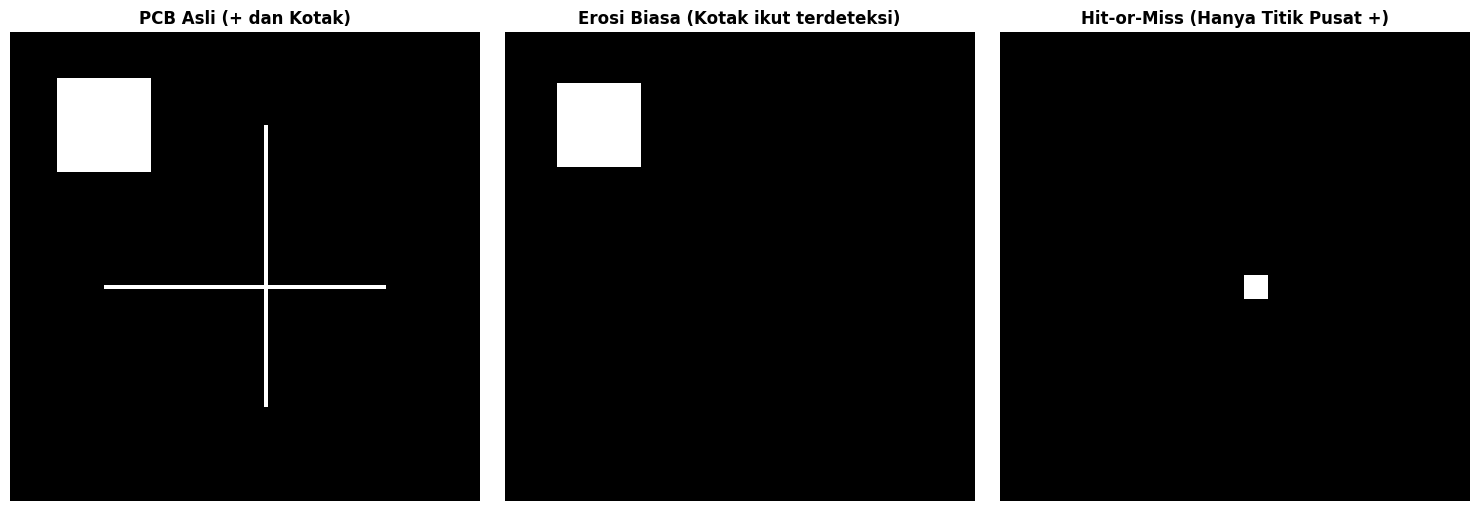

In [4]:
# 1. MENSINTESIS PAPAN SIRKUIT (Biner)
pcb = np.zeros((100, 100), dtype=np.uint8)
pcb[20:80, 54:55] = 255 # Garis vertikal panjang
pcb[54:55, 20:80] = 255 # Garis horizontal panjang (Membentuk Tanda Tambah +)
pcb[10:30, 10:30] = 255 # Objek Kotak Pengecoh

# 2. DEFINISIKAN STRUCTURING ELEMENT HIT-OR-MISS
# Kita ingin mencari titik TEPAT di mana persimpangan (Cross) terjadi.
# 1 = Harus Putih (Objek), -1 = Harus Hitam (Background), 0 = Abaikan (Boleh apa saja)
kernel_hitmiss = np.array([
    [-1,  1, -1],
    [ 1,  1,  1],
    [-1,  1, -1]
], dtype=np.int8) # Harus int8 karena ada nilai negatif

# 3. EKSPERIMEN
# Erosi biasa: Akan bernilai positif pada persimpangan, TAPI juga positif pada Kotak!
kernel_erosi = np.array([[1,1,1],[1,1,1],[1,1,1]], dtype=np.uint8)
hasil_erosi_biasa = cv2.erode(pcb, kernel_erosi)

# Hit-or-Miss: Hanya bernilai positif di titik yang bentuk DAN latar belakangnya cocok
hasil_hitmiss = cv2.morphologyEx(pcb, cv2.MORPH_HITMISS, kernel_hitmiss)

# Perbesar titik hasil agar terlihat di layar
hasil_hitmiss_tampil = cv2.dilate(hasil_hitmiss, np.ones((5,5), np.uint8))

tampilkan_perbandingan(
    ["PCB Asli (+ dan Kotak)", "Erosi Biasa (Kotak ikut terdeteksi)", "Hit-or-Miss (Hanya Titik Pusat +)"],
    [pcb, hasil_erosi_biasa, hasil_hitmiss_tampil]
)